## <div align="center"> LAB IS411 Data Modelling </div>
## <div align="center"> Digital Learning Analytics Analysis</div>
#### <div align="center"> Even Semester 2025/2026 </div>
---

In [1]:
import datetime
import uuid

In [2]:
import datetime
import uuid

studentName = "Arya Pannadana, Nikki Tirta Iwan, Wibisana Theomen Kasriady, Alexander William"
studentNIM = "00000107859, 00000112922 , 00000119106, 00000108937"
studentClass = "IS411-EL"

In [3]:
myDate = datetime.datetime.now()
myDevice = str(uuid.uuid1())

print("Name: \t\t{}".format(studentName))
print("NIM: \t\t{}".format(studentNIM))
print("Class: \t\t{}".format(studentClass))
print("Start: \t\t{}".format(myDate))
print("Device ID: \t{}".format(myDevice))

Name: 		Arya Pannadana, Nikki Tirta Iwan, Wibisana Theomen Kasriady, Alexander William
NIM: 		00000107859, 00000112922 , 00000119106, 00000108937
Class: 		IS411-EL
Start: 		2026-05-29 13:24:16.570272
Device ID: 	04b02d9a-5b27-11f1-b958-5ec0b7ae6c97


---
## <div align="center"> LIBRARY </div>
---

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, chi2, RFE
from sklearn.preprocessing import PolynomialFeatures

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import xgboost as xgb
from xgboost import XGBRegressor
import optuna

---
## <div align="center"> DATA UNDERSTANDING </div>
---

#### LOAD, CHECK, AND BASIC STATISTICAL DATA

In [5]:
dla = pd.read_csv("digital_learning_analytics_100k.csv")
dla.head()

,learner_id,age,gender,education_level,country,employment_status,prior_online_courses,digital_literacy_score,app_category,daily_app_minutes,...,content_recommendations_followed,knowledge_gaps_identified,remediation_modules_completed,time_to_mastery_hours,mastery_score,learning_efficiency_score,enrollment_date,last_activity_date,total_learning_hours,engagement_consistency
0,LRN00000001,28,Non-binary,Graduate,Australia,Student,0,8.04,Test Prep,85.0,...,47.5,2,0,21.0,44.2,21.05,2022-07-03,2022-07-16,34.2,0.527
1,LRN00000002,33,Male,Graduate,United States,Retired,7,7.07,Mathematics,54.2,...,35.9,10,2,22.4,13.0,5.80,2024-09-24,2024-10-17,34.9,0.441
2,LRN00000003,20,Male,Professional Certificate,India,Employed Full-time,6,7.79,Language Learning,53.4,...,40.6,4,0,70.5,43.2,6.13,2022-03-25,2022-04-04,37.8,0.494
3,LRN00000004,27,Female,Doctoral,South Africa,Self-employed,5,7.24,Test Prep,60.3,...,42.5,0,0,39.1,44.6,11.41,2025-01-13,2025-02-04,41.7,0.493
4,LRN00000005,50,Male,Some College,Germany,Unemployed,5,4.77,Soft Skills,31.8,...,47.4,2,0,52.6,35.1,6.67,2024-09-27,2024-11-01,36.9,0.305


In [6]:
dla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   learner_id                        100000 non-null  object 
 1   age                               100000 non-null  int64  
 2   gender                            100000 non-null  object 
 3   education_level                   100000 non-null  object 
 4   country                           100000 non-null  object 
 5   employment_status                 100000 non-null  object 
 6   prior_online_courses              100000 non-null  int64  
 7   digital_literacy_score            100000 non-null  float64
 8   app_category                      100000 non-null  object 
 9   daily_app_minutes                 100000 non-null  float64
 10  session_count_weekly              100000 non-null  int64  
 11  app_completion_rate               100000 non-null  fl

In [7]:
col_stat = 'total_learning_hours'
print(f"Statistik Deskriptif Mendalam untuk: {col_stat}")
print(f"Mean (Rata-rata)      : {dla[col_stat].mean():.2f}")
print(f"Median (Nilai Tengah) : {dla[col_stat].median():.2f}")
print(f"Mode (Modus)          : {dla[col_stat].mode()[0]:.2f}")
print(f"Range (Jangkauan)     : {dla[col_stat].max() - dla[col_stat].min():.2f}")
print(f"Variance (Varians)    : {dla[col_stat].var():.2f}")
print(f"Std Deviation (SD)    : {dla[col_stat].std():.2f}")
print(f"Skewness              : {dla[col_stat].skew():.2f}")
print(f"Kurtosis              : {dla[col_stat].kurtosis():.2f}")

Statistik Deskriptif Mendalam untuk: total_learning_hours
Mean (Rata-rata)      : 44.95
Median (Nilai Tengah) : 31.80
Mode (Modus)          : 24.10
Range (Jangkauan)     : 882.60
Variance (Varians)    : 1657.18
Std Deviation (SD)    : 40.71
Skewness              : 3.76
Kurtosis              : 24.44


---
## <div align="center"> VISUALISASI DISTRIBUSI DATA </div>
##### <div align="center"> [RQ 1] Bagaimana peta distribusi volume pelajar dan performa kursus pada berbagai platform pembelajaran digital (MOOC)? </div>
---

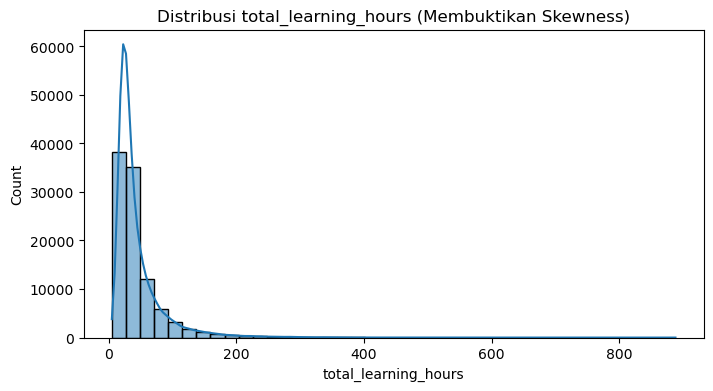

In [8]:
plt.figure(figsize = (8, 4))
sns.histplot(dla[col_stat], kde = True, bins = 40)
plt.title(f'Distribusi {col_stat} (Membuktikan Skewness)')
plt.show()

C:\Users\aryap\AppData\Local\Temp\ipykernel_25716\2660494623.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = dla, x = 'course_completed', palette = 'viridis')


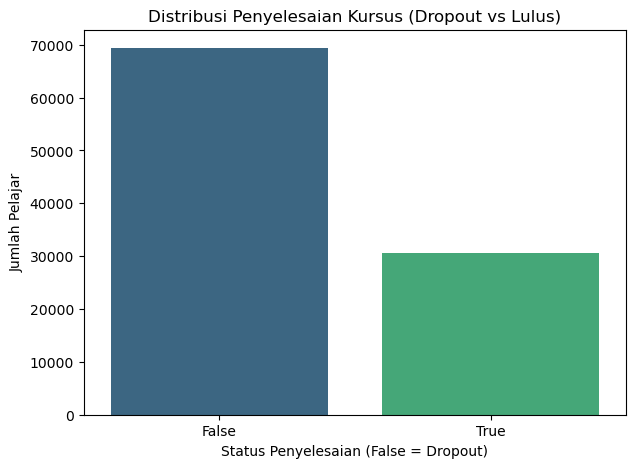

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(data = dla, x = 'course_completed', palette = 'viridis')
plt.title('Distribusi Penyelesaian Kursus (Dropout vs Lulus)')
plt.ylabel('Jumlah Pelajar')
plt.xlabel('Status Penyelesaian (False = Dropout)')
plt.show()

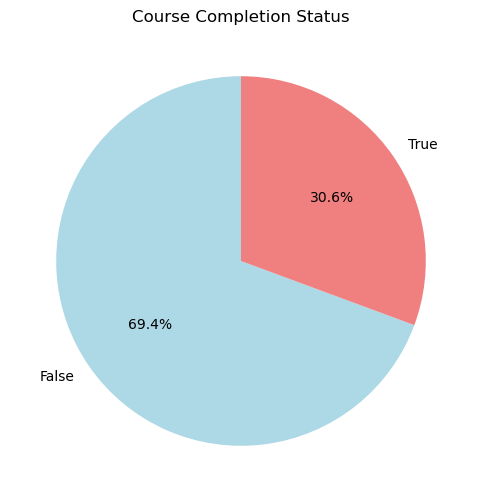

In [10]:
counts = dla["course_completed"].value_counts()
counts.plot.pie(autopct='%1.1f%%', startangle=90, figsize=(6, 6), colors=['lightblue', 'lightcoral'])
plt.title("Course Completion Status")
plt.ylabel("")
plt.show()

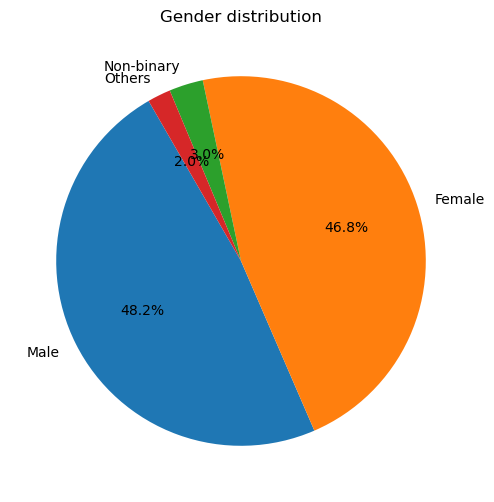

In [11]:
counts = dla["gender"].value_counts()
top3_gender = counts.nlargest(3)
if len(counts) > 3:
    top3_gender['Others'] = counts.iloc[3:].sum()
top3_gender.plot.pie(autopct='%1.1f%%', startangle=120, figsize=(6, 6))
plt.title("Gender distribution")
plt.ylabel("")
plt.show()

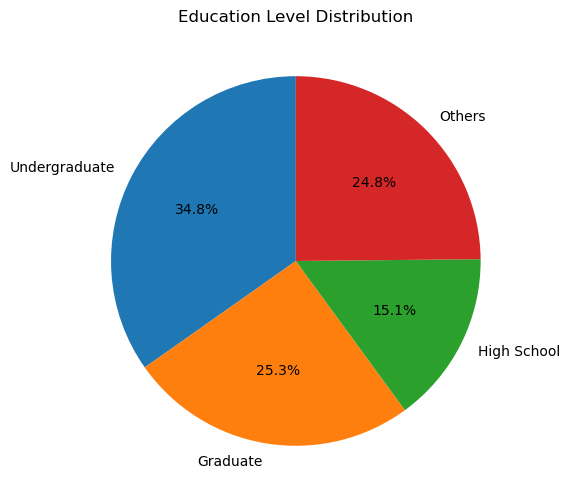

In [12]:
counts = dla["education_level"].value_counts()
top3_ed = counts.nlargest(3)
if len(counts) > 3:
    top3_ed['Others'] = counts.iloc[3:].sum()
top3_ed.plot.pie(autopct='%1.1f%%', startangle=90, figsize=(6,6))
plt.title("Education Level Distribution")
plt.ylabel("")
plt.show()

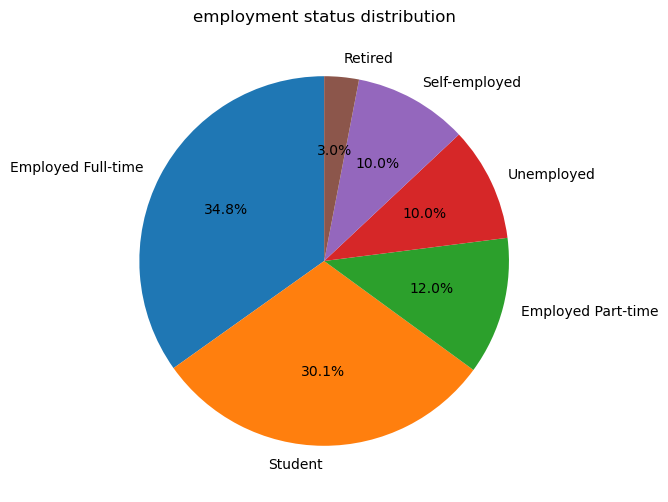

In [13]:
counts = dla["employment_status"].value_counts()
top3_emp = counts.nlargest(3)
if len(counts) > 3:
    top3_emp['Others'] = counts.iloc[3:].sum()
counts.plot.pie(autopct='%1.1f%%', startangle=90, figsize=(6, 6))
plt.title("employment status distribution")
plt.ylabel("")
plt.show()

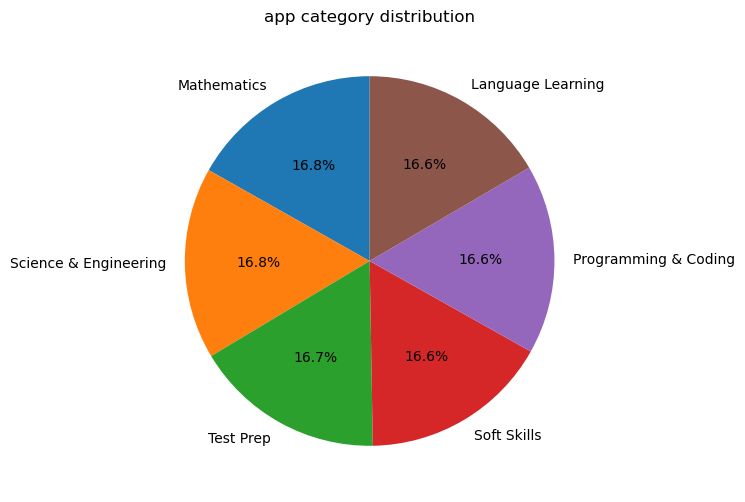

In [14]:
counts = dla["app_category"].value_counts()
top3_app = counts.nlargest(5)
if len(counts) > 5:
    top3_app['Others'] = counts.iloc[5:].sum()
counts.plot.pie(autopct='%1.1f%%', startangle=90, figsize=(6, 6))
plt.title("app category distribution")
plt.ylabel("")
plt.show()

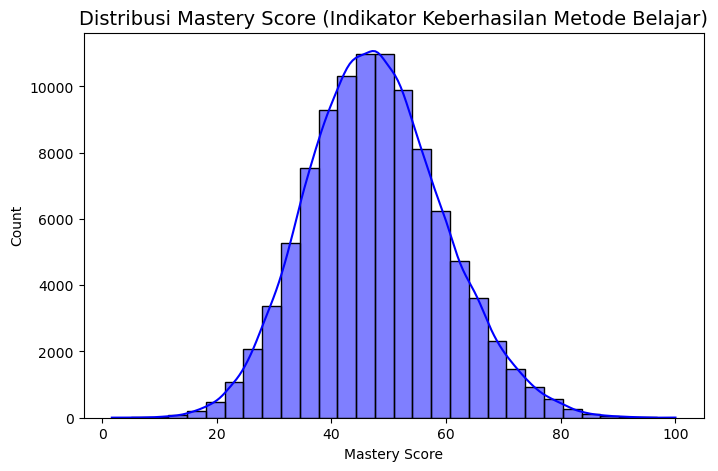

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(dla['mastery_score'], bins=30, kde=True, color='blue')
plt.title('Distribusi Mastery Score (Indikator Keberhasilan Metode Belajar)', fontsize=14)
plt.xlabel('Mastery Score')
plt.show()

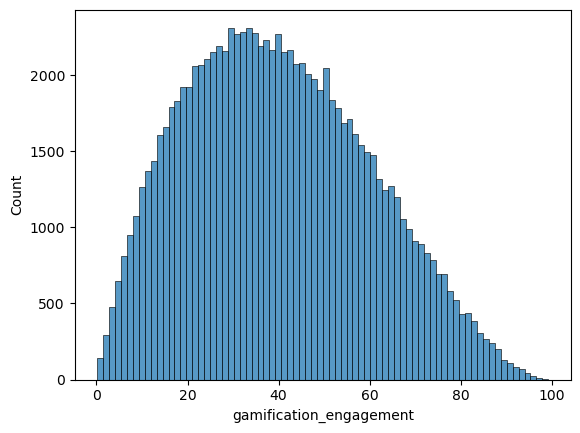

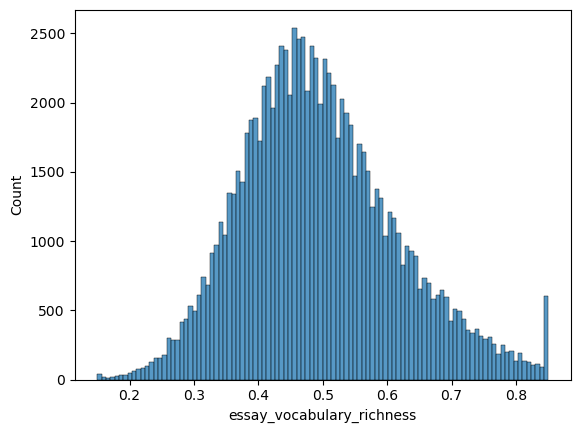

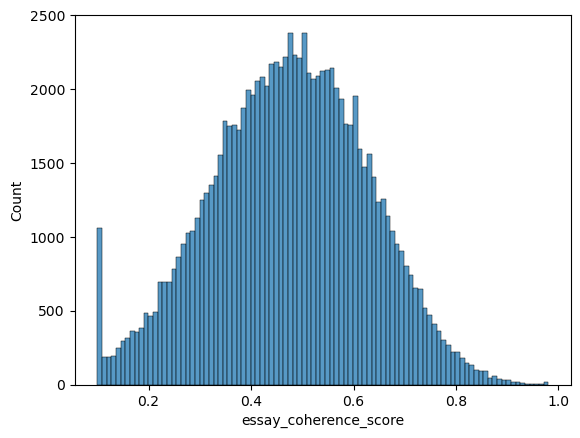

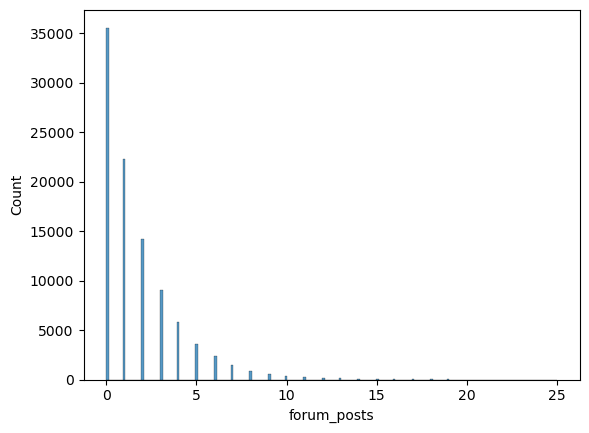

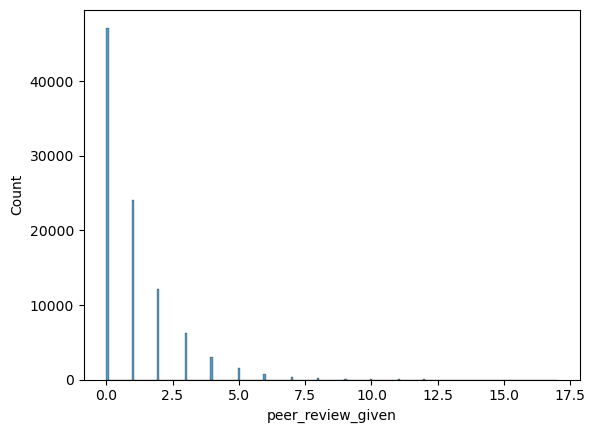

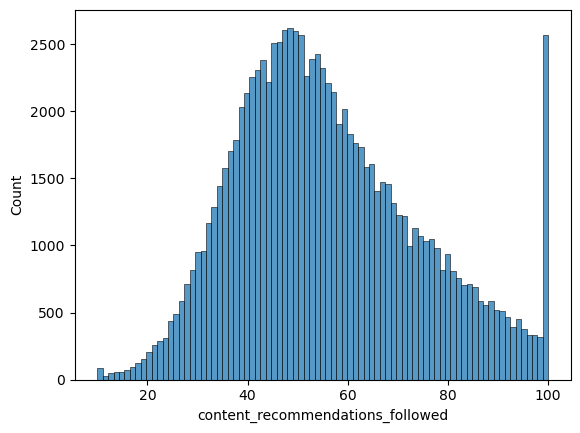

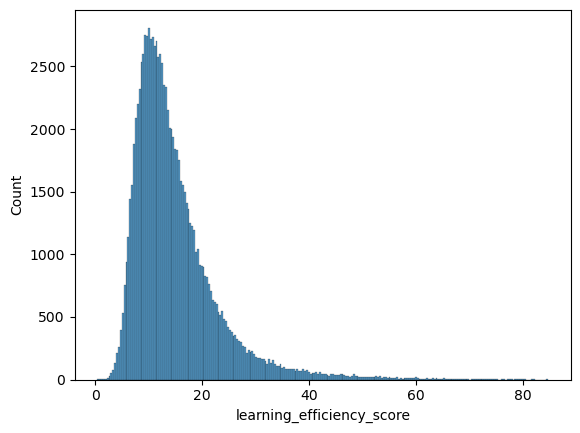

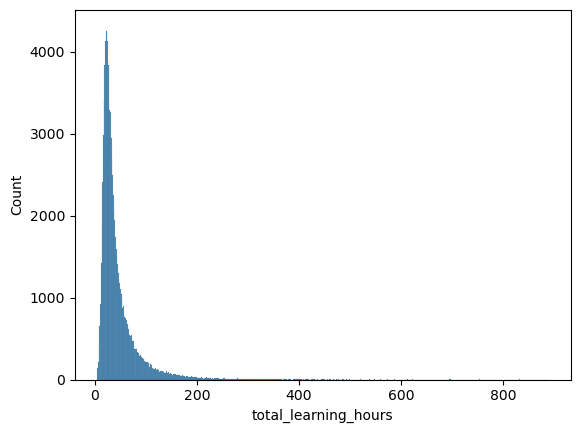

In [16]:
sns.histplot(data=dla["gamification_engagement"])
plt.show()

sns.histplot(data=dla["essay_vocabulary_richness"])
plt.show()

sns.histplot(data=dla["essay_coherence_score"])
plt.show()

sns.histplot(data=dla["forum_posts"])
plt.show()

sns.histplot(data=dla["peer_review_given"])
plt.show()

sns.histplot(data=dla["content_recommendations_followed"])
plt.show()

sns.histplot(data=dla["learning_efficiency_score"])
plt.show()

sns.histplot(data=dla["total_learning_hours"])
plt.show()

---
## <div align="center"> DATA PREPROCESSING & FEATURE ENGINEERING </div>
---

#### MISSING VALUES & DUPLICATES

In [17]:
print(dla.duplicated().sum(), "baris duplikat ditemukan.")
print()
dla.isnull().sum()

0 baris duplikat ditemukan.



learner_id                             0
age                                    0
gender                                 0
education_level                        0
country                                0
employment_status                      0
prior_online_courses                   0
digital_literacy_score                 0
app_category                           0
daily_app_minutes                      0
session_count_weekly                   0
app_completion_rate                    0
in_app_quiz_score                      0
gamification_engagement             2490
skill_pre_score                        0
skill_post_score                       0
essay_topic_category                   0
essay_word_count                       0
essay_grammar_errors                   0
essay_vocabulary_richness           1973
essay_coherence_score               2022
human_grader_score                     0
automated_score                        0
mooc_platform                          0
course_category 

In [18]:
target = [
    "gamification_engagement",
    "essay_vocabulary_richness",
    "essay_coherence_score",
    "content_recommendations_followed",
    "learning_efficiency_score"
]
dla[target] = dla[target].fillna(dla[target].mean())
dla.dropna(inplace=True)
dla.isnull().sum()

learner_id                          0
age                                 0
gender                              0
education_level                     0
country                             0
employment_status                   0
prior_online_courses                0
digital_literacy_score              0
app_category                        0
daily_app_minutes                   0
session_count_weekly                0
app_completion_rate                 0
in_app_quiz_score                   0
gamification_engagement             0
skill_pre_score                     0
skill_post_score                    0
essay_topic_category                0
essay_word_count                    0
essay_grammar_errors                0
essay_vocabulary_richness           0
essay_coherence_score               0
human_grader_score                  0
automated_score                     0
mooc_platform                       0
course_category                     0
course_duration_weeks               0
video_comple

#### FEATURE ENGINEERING

In [19]:
dla['score_improvement'] = dla['skill_post_score'] - dla['skill_pre_score']
dla['total_interactions'] = dla['forum_posts'] + dla['peer_review_given'] + dla['content_recommendations_followed']

#### OUTLIER HANDLING [IQR METHOD]

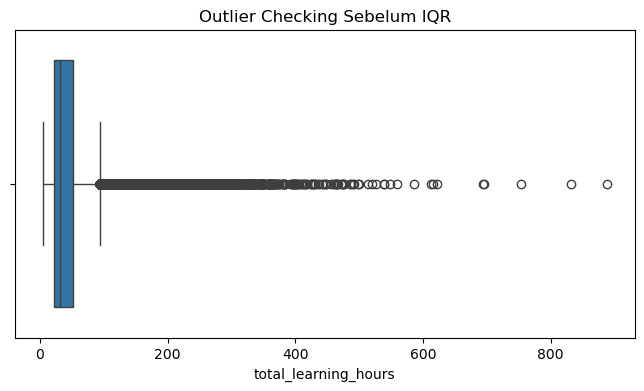

In [20]:

plt.figure(figsize=(8, 4))
sns.boxplot(x=dla['total_learning_hours'])
plt.title('Outlier Checking Sebelum IQR')
plt.show()

In [21]:
data_clean = dla["total_learning_hours"]
skew_value = data_clean.skew()
kurt_value = data_clean.kurt()
print(f"Skewness: {skew_value:.3f}")
print(f"Kurtosis: {kurt_value:.3f}")
print("high skew (to right) and leptokurtic")

Skewness: 3.763
Kurtosis: 24.726
high skew (to right) and leptokurtic


In [22]:
Q1 = dla['total_learning_hours'].quantile(0.25)
Q3 = dla['total_learning_hours'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

In [23]:
dla['total_learning_hours'] = np.where(dla['total_learning_hours'] > batas_atas, batas_atas,
                              np.where(dla['total_learning_hours'] < batas_bawah, batas_bawah, dla['total_learning_hours']))

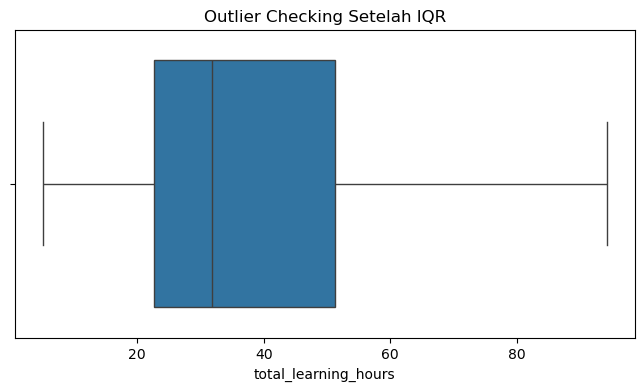

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=dla['total_learning_hours'])
plt.title('Outlier Checking Setelah IQR')
plt.show()

---
## <div align="center"> DATA TRANSFORMATION & FEATURE SELECTION </div>
---

#### ENCODING

In [25]:
dlanew = dla.dropna()

In [26]:
country_oneHot = pd.get_dummies(dlanew['country'], prefix='country', dtype=int)
cat_cols = dlanew.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols if 'date' not in col.lower()]

In [27]:
le = LabelEncoder()
for col in cat_cols:
    dlanew[col] = le.fit_transform(dlanew[col])

In [28]:
if dlanew['course_completed'].dtype == bool or dlanew['course_completed'].dtype == object:
    dlanew['course_completed'] = dlanew['course_completed'].astype(int)

#### STANDARIZATION

In [29]:
cols_to_exclude = ['course_completed', 'learner_id']
num_cols = dlanew.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()
num_cols = [col for col in num_cols if col not in cols_to_exclude]

In [30]:
scaler = StandardScaler()
dlanew[num_cols] = scaler.fit_transform(dlanew[num_cols])
display(dlanew.head())

,learner_id,age,gender,education_level,country,employment_status,prior_online_courses,digital_literacy_score,app_category,daily_app_minutes,...,remediation_modules_completed,time_to_mastery_hours,mastery_score,learning_efficiency_score,enrollment_date,last_activity_date,total_learning_hours,engagement_consistency,score_improvement,total_interactions
0,0,-0.502972,2.155892,-1.137899,-1.674419,0.946051,-0.905475,1.314174,1.465803,1.754505,...,-0.855380,-1.322571,-0.303649,0.754841,2022-07-03,2022-07-16,-0.252835,0.183533,0.555997,-0.558350
1,1,-0.113487,0.613828,-1.137899,1.171735,-0.095754,0.500951,0.592307,-0.878655,0.388831,...,1.130741,-1.206161,-2.936433,-1.131081,2024-09-24,2024-10-17,-0.223762,-0.247379,-0.838804,-1.238332
2,2,-1.126149,0.613828,-0.005982,-0.725701,-1.137560,0.300033,1.128126,-1.464769,0.353359,...,-0.855380,2.793353,-0.388034,-1.090271,2022-03-25,2022-04-04,-0.103321,0.018183,-0.215113,-0.876754
3,3,-0.580870,-0.928236,-1.703858,0.638081,0.425148,0.099115,0.718820,1.465803,0.659306,...,-0.855380,0.182443,-0.269896,-0.437309,2025-01-13,2025-02-04,0.058652,0.013172,0.601357,-0.666283
4,4,1.210764,0.613828,0.559977,-0.903586,1.466954,0.099115,-1.119336,0.879688,-0.604386,...,-0.855380,1.304968,-1.071545,-1.023491,2024-09-27,2024-11-01,-0.140699,-0.928821,-0.509949,-0.455813


#### FEATURE SELECTION [CORRELATION TESTS]

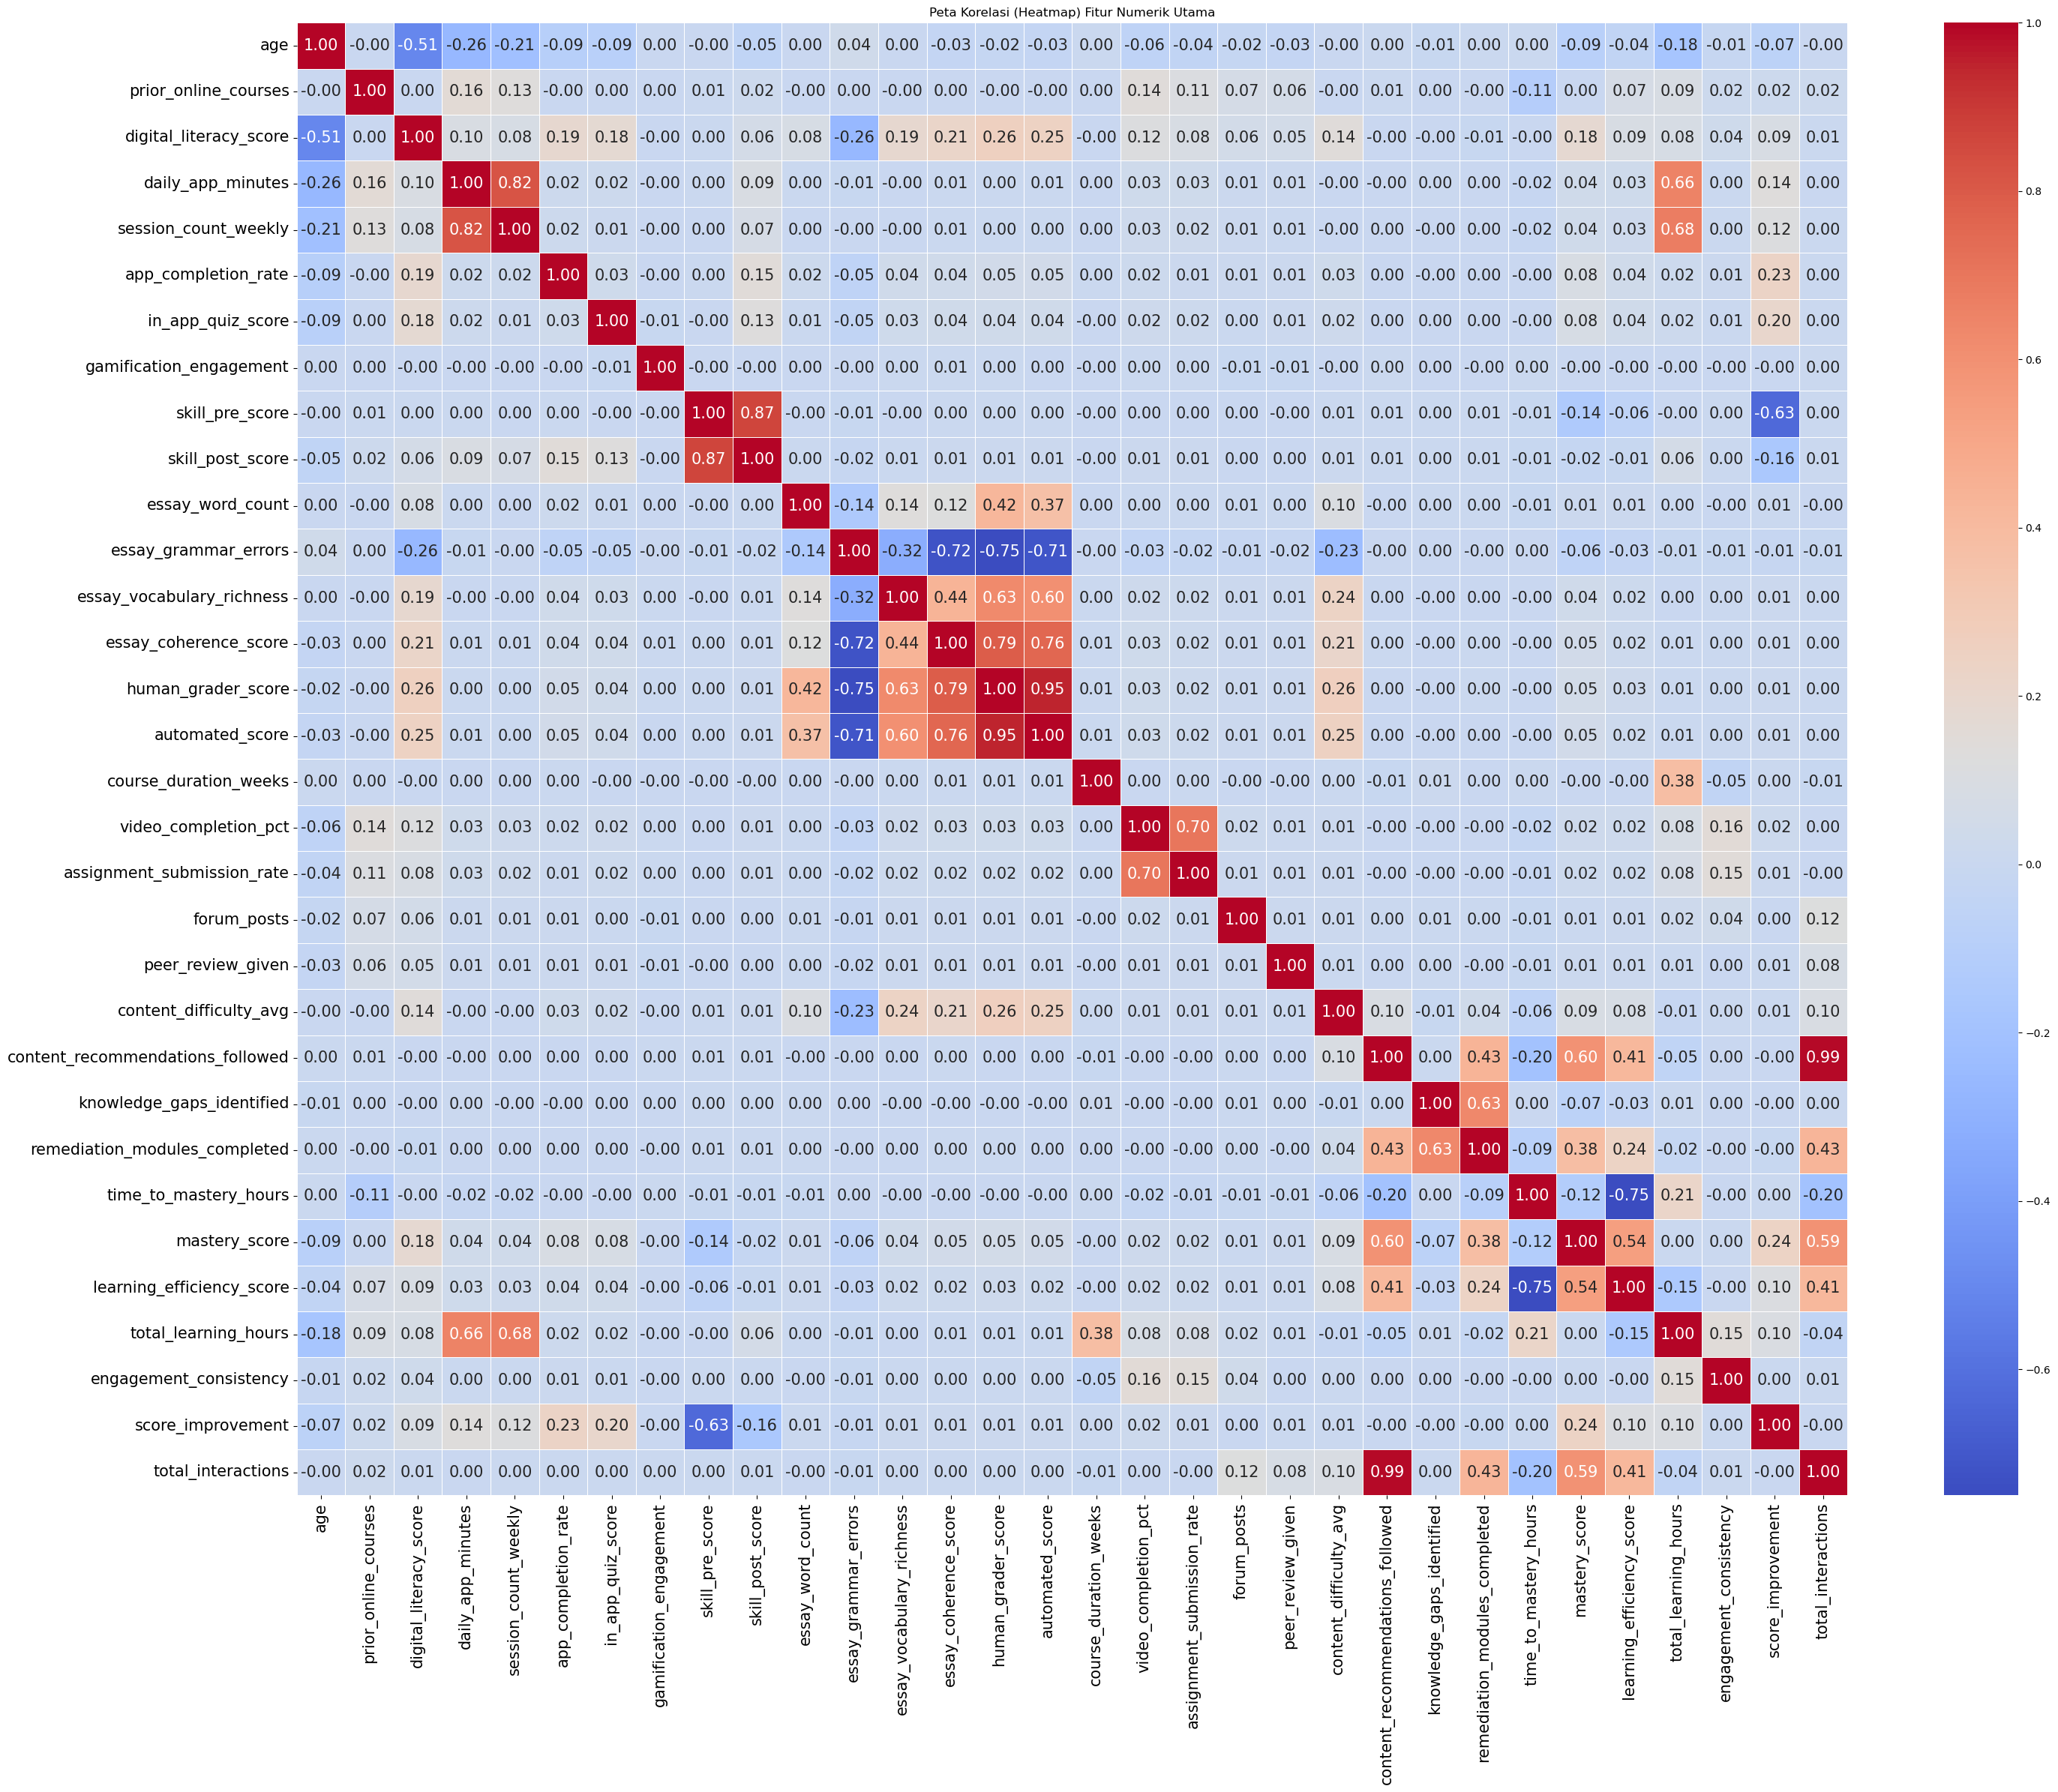

In [31]:
selected_cols = dla.select_dtypes(include='number')
corrMat = selected_cols.corr()
plt.figure(figsize=(30, 24))
sns.heatmap(corrMat, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, annot_kws={"size": 15})
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.title('Peta Korelasi (Heatmap) Fitur Numerik Utama')
plt.tight_layout()
plt.show()

In [32]:
Dropped_colm = ['course_completed', 'enrollment_date', 'last_activity_date', 'learner_id']
X = dlanew.drop(columns=Dropped_colm)
y = dlanew['course_completed']

#### ANOVA F-Test

In [33]:
selector_anova = SelectKBest(score_func=f_classif, k=2)
X_new_anova = selector_anova.fit_transform(X, y)
print("ANOVA F-test scores:", selector_anova.scores_)
print("Selected features (ANOVA):", X.columns[selector_anova.get_support()])

ANOVA F-test scores: [4.40419025e+01 3.94259594e-01 1.43878081e+01 8.54489983e-01
 1.34646552e+00 9.52655043e+01 2.51164978e+02 4.11800729e-03
 1.34381409e+01 8.73588142e+00 8.35910126e+00 1.14626425e+01
 6.40158484e-01 1.43507429e-01 2.28045183e+00 9.06153909e-02
 1.03434034e+00 1.37417926e+01 1.18818296e+01 7.00942755e+00
 9.34550910e+00 6.61549266e+00 3.91270356e-01 4.27360817e+00
 4.60635774e+02 5.10026147e+03 4.95909880e+03 3.74743850e+02
 2.28137287e-01 1.10676876e+00 7.61288883e+00 9.12051034e-03
 5.82350593e-01 8.88075445e-01 2.88825754e+00 6.11408320e+00
 2.05167905e+00 4.80359356e+03 7.89986801e+04 2.61307641e+00
 5.90273028e+00]
Selected features (ANOVA): Index(['video_completion_pct', 'engagement_consistency'], dtype='object')


#### RFE (Recursive Feature Elimination)

In [34]:
dectree = DecisionTreeClassifier(random_state=42)
selector_rfe = RFE(estimator=dectree, n_features_to_select=5)
selector_rfe.fit(X, y)
feature_df = pd.DataFrame({
    'Column': X.columns,
    'Feature': [f'Feature {i}' for i in range(X.shape[1])],
    'Selected': selector_rfe.support_,
    'Ranking': selector_rfe.ranking_
})
print(feature_df.sort_values(by='Ranking'))

                              Column     Feature  Selected  Ranking
8                  daily_app_minutes   Feature 8      True        1
26        assignment_submission_rate  Feature 26      True        1
38            engagement_consistency  Feature 38      True        1
37              total_learning_hours  Feature 37      True        1
36         learning_efficiency_score  Feature 36      True        1
25              video_completion_pct  Feature 25     False        2
12           gamification_engagement  Feature 12     False        3
34             time_to_mastery_hours  Feature 34     False        4
30            content_difficulty_avg  Feature 30     False        5
9               session_count_weekly   Feature 9     False        6
24             course_duration_weeks  Feature 24     False        7
10               app_completion_rate  Feature 10     False        8
14                  skill_post_score  Feature 14     False        9
16                  essay_word_count  Feature 16

## SEGMENTATION USING FEATURE IMPORTANCE

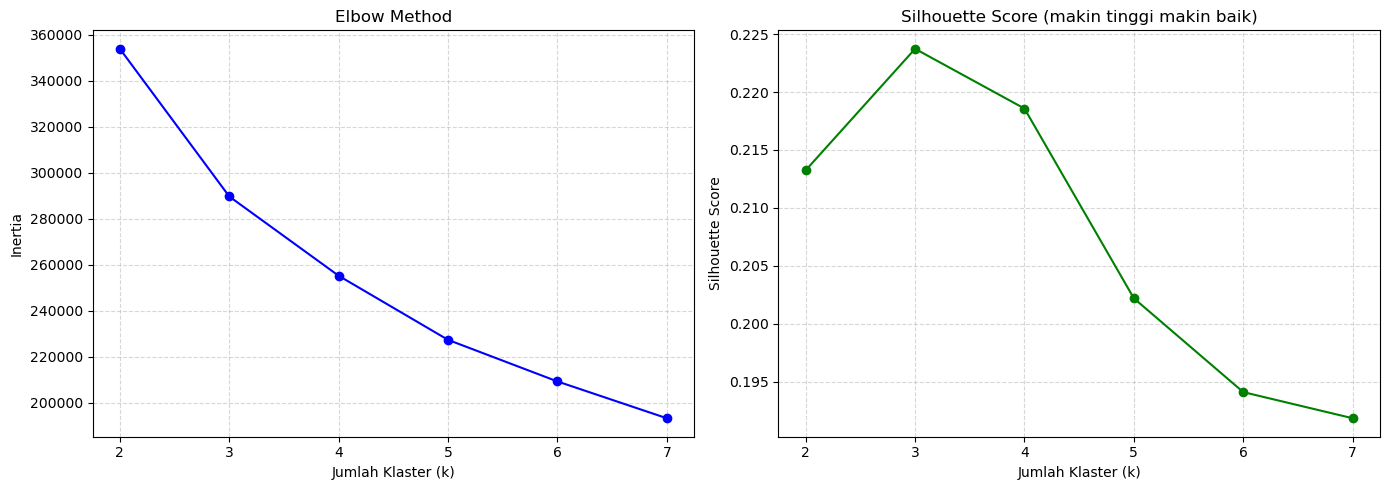

Silhouette scores per k:
  k=2: 0.2132
  k=3: 0.2237
  k=4: 0.2186
  k=5: 0.2022
  k=6: 0.1941
  k=7: 0.1918


In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

fitur_terpilih = [
    'total_learning_hours',
    'course_duration_weeks',
    'assignment_submission_rate',
    'engagement_consistency',
    'video_completion_pct'
]

X_segmentasi = dlanew[fitur_terpilih].copy()

# Elbow Method
inertia = []
sil_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_segmentasi)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_segmentasi, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, 'bo-')
axes[0].set_xlabel('Jumlah Klaster (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(k_range, sil_scores, 'go-')
axes[1].set_xlabel('Jumlah Klaster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (makin tinggi makin baik)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Silhouette scores per k:")
for k, s in zip(k_range, sil_scores):
    print(f"  k={k}: {s:.4f}")

PCA 1 menjelaskan : 36.0%
PCA 2 menjelaskan : 27.2%
Total 2 komponen  : 63.2% dari variansi data



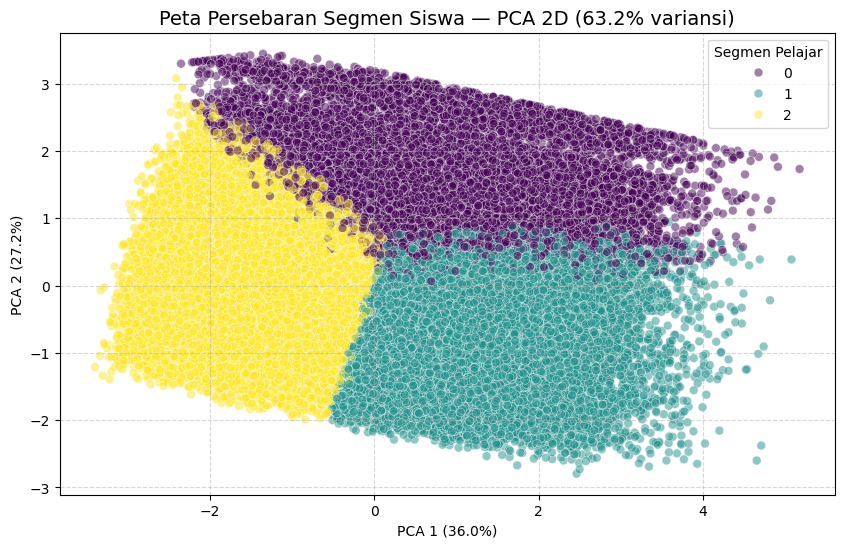


Rata-rata fitur per segmen (skala ter-scale):


,total_learning_hours,course_duration_weeks,assignment_submission_rate,engagement_consistency,video_completion_pct
Segmen_Pelajar,,,,,
0,1.539,0.858,0.161,0.289,0.177
1,-0.421,-0.330,0.777,0.189,0.767
2,-0.422,-0.150,-0.777,-0.319,-0.777


In [36]:
# k optimal + PCA diagnostic
from sklearn.decomposition import PCA

k_optimal = 3

df_final = dlanew.copy()

kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_final['Segmen_Pelajar'] = kmeans_model.fit_predict(X_segmentasi)

# Cek explained variance PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_segmentasi)
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
total_var = var1 + var2

print(f"PCA 1 menjelaskan : {var1:.1f}%")
print(f"PCA 2 menjelaskan : {var2:.1f}%")
print(f"Total 2 komponen  : {total_var:.1f}% dari variansi data")
print()

# Plot scatter PCA
df_pca = pd.DataFrame(X_pca, columns=['Komponen_1', 'Komponen_2'])
df_pca['Segmen_Pelajar'] = df_final['Segmen_Pelajar'].values

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Komponen_1', y='Komponen_2',
    hue='Segmen_Pelajar',
    palette='viridis',
    data=df_pca,
    s=40, alpha=0.5
)
plt.title(f'Peta Persebaran Segmen Siswa — PCA 2D ({total_var:.1f}% variansi)', fontsize=14)
plt.xlabel(f'PCA 1 ({var1:.1f}%)')
plt.ylabel(f'PCA 2 ({var2:.1f}%)')
plt.legend(title='Segmen Pelajar')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Profil tiap segmen (interpretasi klaster)
print("\nRata-rata fitur per segmen (skala ter-scale):")
display(df_final.groupby('Segmen_Pelajar')[fitur_terpilih].mean().round(3))

---
## <div align="center"> CLASSIFICATION </div>
#### <div align="center"> [RQ 2] Faktor-faktor interaksi dan demografi apa saja yang paling memengaruhi tingkat retensi serta memicu titik jenuh (churn/dropout) pelajar? </div>
---

##### RESAMPLING DENGAN SMOTE UNTUK MODEL RFC

In [37]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

#### XGBOOST CLASSIFIER

In [38]:
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_clf.fit(X_resampled, y_resampled)
y_pred_xgb = xgb_clf.predict(X_test)

#### LightGBM Classifier

In [39]:
lgbm_clf = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
lgbm_clf.fit(X_resampled, y_resampled)
y_pred_lgbm = lgbm_clf.predict(X_test)

[LightGBM] [Info] Number of positive: 64523, number of negative: 64523
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10448
[LightGBM] [Info] Number of data points in the train set: 129046, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


##### FEATURE IMPORTANCE

In [40]:
importance_scores = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

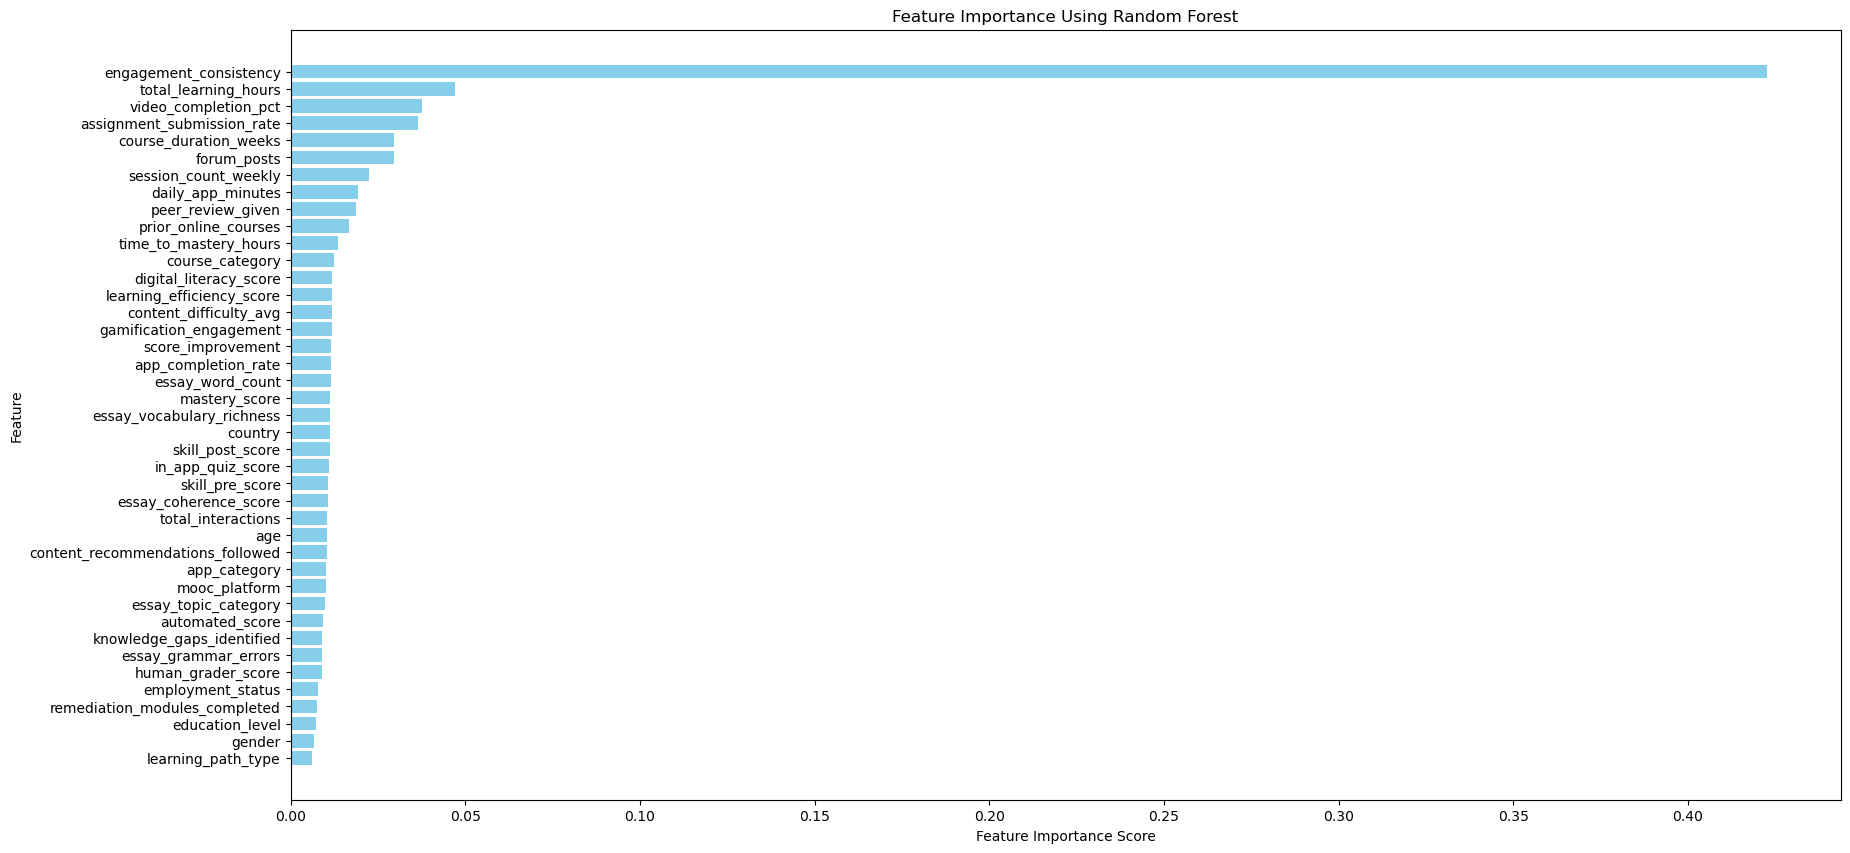

In [41]:
plt.figure(figsize=(20, 10))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance Using Random Forest")
plt.gca().invert_yaxis()
plt.show()

##### OPTUNA LOGISTIC REGRESSION

In [42]:
def objective(trial):
    c_param = trial.suggest_float('C', 1e-5, 100, log=True)
    solver_param = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
    weight_param = trial.suggest_categorical('class_weight', [None, 'balanced'])
    clf = LogisticRegression(C=c_param, solver=solver_param, max_iter=2000, random_state=42)
    score = cross_val_score(clf, X, y, cv=3).mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)
print("Best hyperparameters:, {study.best_params}")

[I 2026-05-29 13:27:24,430] A new study created in memory with name: no-name-b0136396-e6ad-45a3-8fab-d4c01cd7776f
[I 2026-05-29 13:27:27,388] Trial 0 finished with value: 0.890669024204214 and parameters: {'C': 14.059834959824649, 'solver': 'saga', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.890669024204214.
[I 2026-05-29 13:27:30,093] Trial 1 finished with value: 0.890669024204214 and parameters: {'C': 19.69936005299775, 'solver': 'saga', 'class_weight': None}. Best is trial 0 with value: 0.890669024204214.
[I 2026-05-29 13:27:32,087] Trial 2 finished with value: 0.8896367942345251 and parameters: {'C': 0.0005708664181910233, 'solver': 'liblinear', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.890669024204214.
[I 2026-05-29 13:27:35,067] Trial 3 finished with value: 0.890669024204214 and parameters: {'C': 27.28321143177561, 'solver': 'saga', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.890669024204214.
[I 2026-05-29 13:27:35,858] Trial 4 finis

Best hyperparameters:, {study.best_params}


#### VISUALISASI OPTUNA

In [43]:
import optuna.visualization as vis


# Visualisasi Riwayat Optimasi (Optimization History)
# Menampilkan grafik perjalanan bagaimana Optuna menemukan nilai akurasi tertinggi dari trial ke trial
fig_history = vis.plot_optimization_history(study)
fig_history.update_layout(title="Riwayat Optimasi Logistic Regression (Optuna)")
fig_history.show()

# 2. Visualisasi Tingkat Kepentingan Parameter (Hyperparameter Importances)
# Menampilkan grafik parameter mana (antara C atau Solver) yang paling dominan memengaruhi akurasi model
fig_importance = vis.plot_param_importances(study)
fig_importance.update_layout(title="Tingkat Kepentingan Hiperparameter (Optuna)")
fig_importance.show()

#### VISUALISASI CONFUSION MATRIX

##### Random Forest Classifier

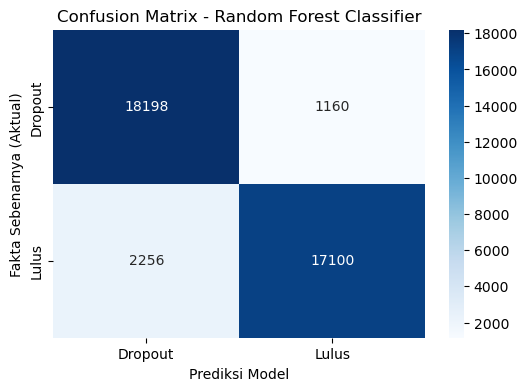

In [44]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dropout', 'Lulus'],
            yticklabels=['Dropout', 'Lulus'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Prediksi Model')
plt.ylabel('Fakta Sebenarnya (Aktual)')
plt.show()

##### XGBoost Classifier

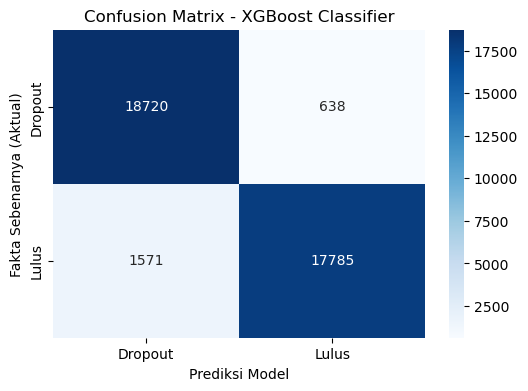

In [45]:
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dropout', 'Lulus'],
            yticklabels=['Dropout', 'Lulus'])
plt.title('Confusion Matrix - XGBoost Classifier')
plt.xlabel('Prediksi Model')
plt.ylabel('Fakta Sebenarnya (Aktual)')
plt.show()

#### LightGBM Classifier

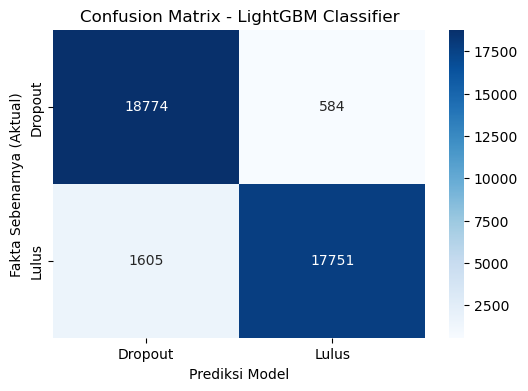

In [46]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dropout', 'Lulus'],
            yticklabels=['Dropout', 'Lulus'])
plt.title('Confusion Matrix - LightGBM Classifier')
plt.xlabel('Prediksi Model')
plt.ylabel('Fakta Sebenarnya (Aktual)')
plt.show()

#### PERBANDINGAN MODEL KLASIFIKASI

In [47]:
print(f"1. Random Forest Classifier Akurasi : {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"2. Logistic Regression (Optuna) Akurasi: {study.best_value * 100:.2f}%")
print(f"3. XGBoost Classifier Akurasi: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"4. LightGBM Classifier Akurasi: {accuracy_score(y_test, y_pred_lgbm) * 100:.2f}%")

1. Random Forest Classifier Akurasi : 91.18%
2. Logistic Regression (Optuna) Akurasi: 89.08%
3. XGBoost Classifier Akurasi: 94.29%
4. LightGBM Classifier Akurasi: 94.35%


In [48]:
#Menggunakan parameter terbaik
best_params = study.best_params
#Mendefinisikan Model Logistic Regression dengan parameter terbaik tersebut
best_lr_model = LogisticRegression(**best_params)
#Melatih (Fit)
best_lr_model.fit(X_train, y_train)
#Melakukan prediksi pada data testing (X_test) untuk membuat variabel y_pred_lr
y_pred_lr = best_lr_model.predict(X_test)


# 1. Random Forest Classifier
print("1. Random Forest Classifier")
print(f"   - Akurasi : {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"   - R2      : {r2_score(y_test, y_pred_rf):.4f}")
print(f"   - MSE     : {mean_squared_error(y_test, y_pred_rf):.4f}")
print(f"   - RMSE    : {mean_squared_error(y_test, y_pred_rf) ** 0.5:.4f}\n")

# 2. Logistic Regression (Optuna)
# Catatan: Asumsi prediksi model dari trial terbaik disimpan dalam y_pred_lr
print("2. Logistic Regression (Optuna)")
print(f"   - Akurasi : {study.best_value * 100:.2f}%")
print(f"   - R2      : {r2_score(y_test, y_pred_lr):.4f}")
print(f"   - MSE     : {mean_squared_error(y_test, y_pred_lr):.4f}")
print(f"   - RMSE    : {mean_squared_error(y_test, y_pred_lr) ** 0.5:.4f}\n")

# 3. XGBoost Classifier

print("3. XGBoost Classifier")
print(f"   - Akurasi : {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"   - R2      : {r2_score(y_test, y_pred_xgb):.4f}")
print(f"   - MSE     : {mean_squared_error(y_test, y_pred_xgb):.4f}")
print(f"   - RMSE    : {mean_squared_error(y_test, y_pred_xgb) ** 0.5:.4f}\n")

# 4. LightGBM Classifier
print("4. LightGBM Classifier")
print(f"   - Akurasi : {accuracy_score(y_test, y_pred_lgbm) * 100:.2f}%")
print(f"   - R2      : {r2_score(y_test, y_pred_lgbm):.4f}")
print(f"   - MSE     : {mean_squared_error(y_test, y_pred_lgbm):.4f}")
print(f"   - RMSE    : {mean_squared_error(y_test, y_pred_lgbm) ** 0.5:.4f}\n")

1. Random Forest Classifier
   - Akurasi : 91.18%
   - R2      : 0.6471
   - MSE     : 0.0882
   - RMSE    : 0.2970

2. Logistic Regression (Optuna)
   - Akurasi : 89.08%
   - R2      : 0.4999
   - MSE     : 0.1250
   - RMSE    : 0.3536

3. XGBoost Classifier
   - Akurasi : 94.29%
   - R2      : 0.7718
   - MSE     : 0.0571
   - RMSE    : 0.2389

4. LightGBM Classifier
   - Akurasi : 94.35%
   - R2      : 0.7738
   - MSE     : 0.0565
   - RMSE    : 0.2378



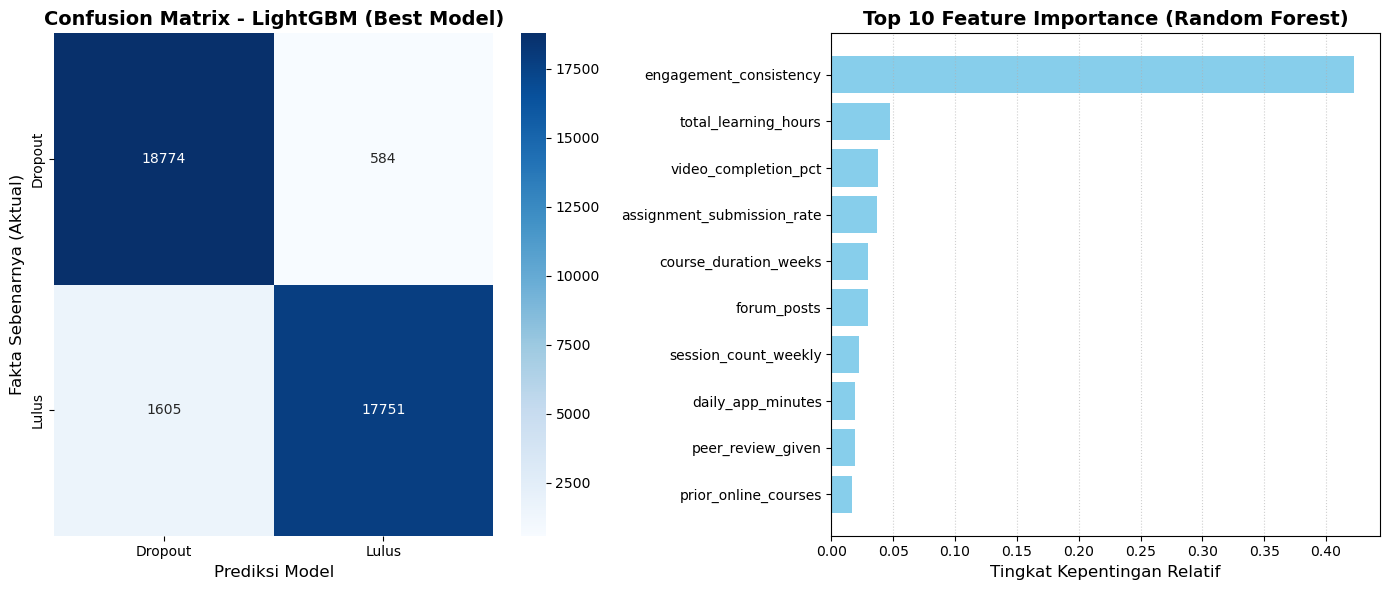

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mengatur ukuran kanvas
plt.figure(figsize=(14, 6))

# 1. Visualisasi Confusion Matrix (LightGBM)
plt.subplot(1, 2, 1)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dropout', 'Lulus'],
            yticklabels=['Dropout', 'Lulus'])
plt.title('Confusion Matrix - LightGBM (Best Model)', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Fakta Sebenarnya (Aktual)', fontsize=12)

# 2. Visualisasi Feature Importance (Random Forest - Sebagai referensi fitur paling berpengaruh)
plt.subplot(1, 2, 2)
# Mengambil importance dari rf_model yang sudah dilatih sebelumnya [cite: 906]
importance_scores = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False).head(10)

plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.title("Top 10 Feature Importance (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Tingkat Kepentingan Relatif", fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### PREDICTION INTO EACH DATA

In [50]:
# Lakukan prediksi pada keseluruhan data fitur (X) menggunakan model terbaik (LightGBM)
prediksi_keseluruhan = lgbm_clf.predict(X)

# Tambahkan kolom baru berisi hasil prediksi (angka 0 dan 1)
df_final['Prediksi_LGBM_Angka'] = prediksi_keseluruhan

# Buat satu kolom lagi untuk menerjemahkan angka menjadi teks agar mudah dibaca
df_final['Status_Prediksi'] = df_final['Prediksi_LGBM_Angka'].map({0: 'Dropout', 1: 'Lulus'})

# membandingkan kolom Aktual (course_completed) vs Prediksi
# Menampilkan 10 data teratas
df_final[['learner_id', 'course_completed', 'Prediksi_LGBM_Angka', 'Status_Prediksi']].head(10)

,learner_id,course_completed,Prediksi_LGBM_Angka,Status_Prediksi
0,0,0,0,Dropout
1,1,0,0,Dropout
2,2,0,0,Dropout
3,3,0,0,Dropout
4,4,0,0,Dropout
5,5,1,1,Lulus
8,6,0,0,Dropout
9,7,1,1,Lulus
10,8,0,0,Dropout
11,9,1,1,Lulus


### DUMMY DATA

In [51]:
import pandas as pd

# Membuat 1 data dummy berbasis struktur X
# ambil nilai rata-rata dari setiap kolom di X sebagai nilai awal (baseline) siswa normal
dummy_student = X.mean().to_frame().T

# Data dummy siswa
dummy_student['total_learning_hours'] = 10
dummy_student['forum_posts'] = 1
dummy_student['gamification_engagement'] = 1600
dummy_student['score_improvement'] = 0


# Scale data
dummy_array_scaled = scaler.transform(dummy_student)

# prediksi menggunakan model LightGBM
prediksi_dummy = lgbm_clf.predict(dummy_array_scaled)

# Terjemahkan hasil prediksi agar mudah dibaca
status = 'Lulus' if prediksi_dummy[0] == 1 else 'Dropout'

# Tampilkan hasil
print("=== HASIL UJI COBA DATA DUMMY ===")
print(f"Berdasarkan rekam jejak yang dimasukkan, model memprediksi siswa ini akan: {status}")

=== HASIL UJI COBA DATA DUMMY ===
Berdasarkan rekam jejak yang dimasukkan, model memprediksi siswa ini akan: Dropout


c:\Users\aryap\anaconda3\envs\arya\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



---
## <div align="center"> REGRESSION </div>
#### <div align="center"> [RQ 3] Faktor apa saja yang paling memengaruhi peningkatan kompetensi siswa (Score Improvement), dan sejauh mana pendekatan algoritma regresi dapat memprediksi nilai tersebut? </div>
---

##### MEMBUANG KOLOM TARGET

In [52]:
Dropped_colm_reg = [
    'learning_efficiency_score',
    'enrollment_date',
    'last_activity_date',
    'learner_id',
    'time_to_mastery_hours',
    'mastery_score'
]

X_reg = dlanew.drop(columns = Dropped_colm_reg, errors = 'ignore')
y_reg = dla['learning_efficiency_score']

##### TESTING MODEL RANDOM FOREST REGRESSION

In [53]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)
rfr_model.fit(X_train_r, y_train_r)

y_pred_r = rfr_model.predict(X_test_r)

r2_rf = r2_score(y_test_r, y_pred_r)
rms_rf = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
mae_rf = mean_absolute_error(y_test_r, y_pred_r)

print(f"R-squared (R2) : {r2_rf}")
print(f"RMSE           : {rms_rf}")
print(f"MAE            : {mae_rf}")

R-squared (R2) : 0.4631164860086565
RMSE           : 5.951813372054346
MAE            : 3.938671415528487


#### LINEAR REGRESSION

In [54]:
lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

# Prediksi dan Evaluasi
lr_predictions = lr_model.predict(X_test_r)
lr_rmse = np.sqrt(mean_squared_error(y_test_r, lr_predictions))
lr_r2 = r2_score(y_test_r, lr_predictions)

print(f"R2 Score : {lr_r2 * 100:.3f}")
print(f"MSE Score : {lr_rmse :.3f}")

R2 Score : 28.001
MSE Score : 6.892


#### TESTING MODEL XGBOOST

In [55]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_r, y_train_r)
y_pred_xgb = xgb_model.predict(X_test_r)

y_pred_xgb = xgb_model.predict(X_test_r)

r2_xg = r2_score(y_test_r, y_pred_xgb)
rms_xg = np.sqrt(mean_squared_error(y_test_r, y_pred_xgb))
mae_xg = mean_absolute_error(y_test_r, y_pred_xgb)

print(f"R-squared (R2) : {r2_xg}")
print(f"RMSE           : {rms_xg}")
print(f"MAE            : {mae_xg}")

R-squared (R2) : 0.5436895583658259
RMSE           : 5.4870570289427665
MAE            : 3.526236922762112


##### TOP 10 FAKTOR BERDASARKAN FEATURE IMPORTANCE

In [56]:
importance_scores_reg = rfr_model.feature_importances_
feature_importance_reg_df = pd.DataFrame({
    'Feature': X_train_r.columns,
    'Importance': importance_scores_reg
}).sort_values(by='Importance', ascending=False).head(10)

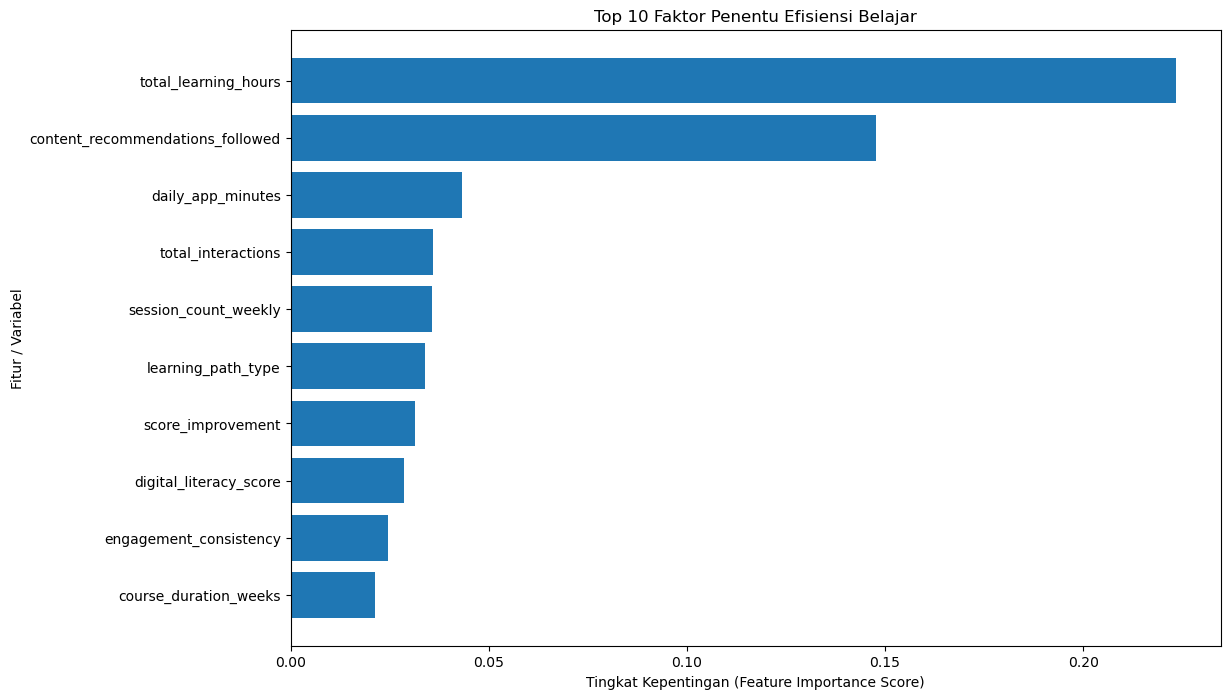

In [57]:
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_reg_df['Feature'], feature_importance_reg_df['Importance'])
plt.xlabel("Tingkat Kepentingan (Feature Importance Score)")
plt.ylabel("Fitur / Variabel")
plt.title("Top 10 Faktor Penentu Efisiensi Belajar")
plt.gca().invert_yaxis()
plt.show()

In [58]:
dla['engagement_consistency'].head()

0    0.527
1    0.441
2    0.494
3    0.493
4    0.305
Name: engagement_consistency, dtype: float64

#### PERBANDINGAN MODEL REGRESI

In [59]:
print("[1] LINEAR REGRESSION")
print(f"R-squared (R2) : {lr_r2:.4f}")
print(f"RMSE           : {lr_rmse:.4f}\n")

print("[2] RANDOM FOREST")
print(f"R-squared (R2) : {r2_rf:.4f}")
print(f"RMSE           : {rms_rf:.4f}\n")

print("[3] XGBOOST REGRESSOR")
print(f"R-squared (R2) : {r2_xg:.4f}")
print(f"RMSE           : {rms_xg:.4f}")

[1] LINEAR REGRESSION
R-squared (R2) : 0.2800
RMSE           : 6.8924

[2] RANDOM FOREST
R-squared (R2) : 0.4631
RMSE           : 5.9518

[3] XGBOOST REGRESSOR
R-squared (R2) : 0.5437
RMSE           : 5.4871


In [60]:
from sklearn.metrics import r2_score, mean_squared_error

# [1] LINEAR REGRESSION
print("[1] LINEAR REGRESSION")
# print(f"   - Akurasi : {accuracy_score(y_test_r, lr_predictions) * 100:.2f}%") # ERROR UNTUK REGRESI
print(f"   - R2      : {r2_score(y_test_r, lr_predictions):.4f}")
print(f"   - MSE     : {mean_squared_error(y_test_r, lr_predictions):.4f}")
print(f"   - RMSE    : {mean_squared_error(y_test_r, lr_predictions) ** 0.5:.4f}\n")

# [2] RANDOM FOREST
print("[2] RANDOM FOREST")
# print(f"   - Akurasi : {accuracy_score(y_test_r, y_pred_r) * 100:.2f}%") # ERROR UNTUK REGRESI
print(f"   - R2      : {r2_score(y_test_r, y_pred_r):.4f}")
print(f"   - MSE     : {mean_squared_error(y_test_r, y_pred_r):.4f}")
print(f"   - RMSE    : {mean_squared_error(y_test_r, y_pred_r) ** 0.5:.4f}\n")

# [3] XGBOOST REGRESSOR
print("[3] XGBOOST REGRESSOR")
# print(f"   - Akurasi : {accuracy_score(y_test_r, y_pred_xgb) * 100:.2f}%") # ERROR UNTUK REGRESI
print(f"   - R2      : {r2_score(y_test_r, y_pred_xgb):.4f}")
print(f"   - MSE     : {mean_squared_error(y_test_r, y_pred_xgb):.4f}")
print(f"   - RMSE    : {mean_squared_error(y_test_r, y_pred_xgb) ** 0.5:.4f}\n")

[1] LINEAR REGRESSION
   - R2      : 0.2800
   - MSE     : 47.5053
   - RMSE    : 6.8924

[2] RANDOM FOREST
   - R2      : 0.4631
   - MSE     : 35.4241
   - RMSE    : 5.9518

[3] XGBOOST REGRESSOR
   - R2      : 0.5437
   - MSE     : 30.1078
   - RMSE    : 5.4871



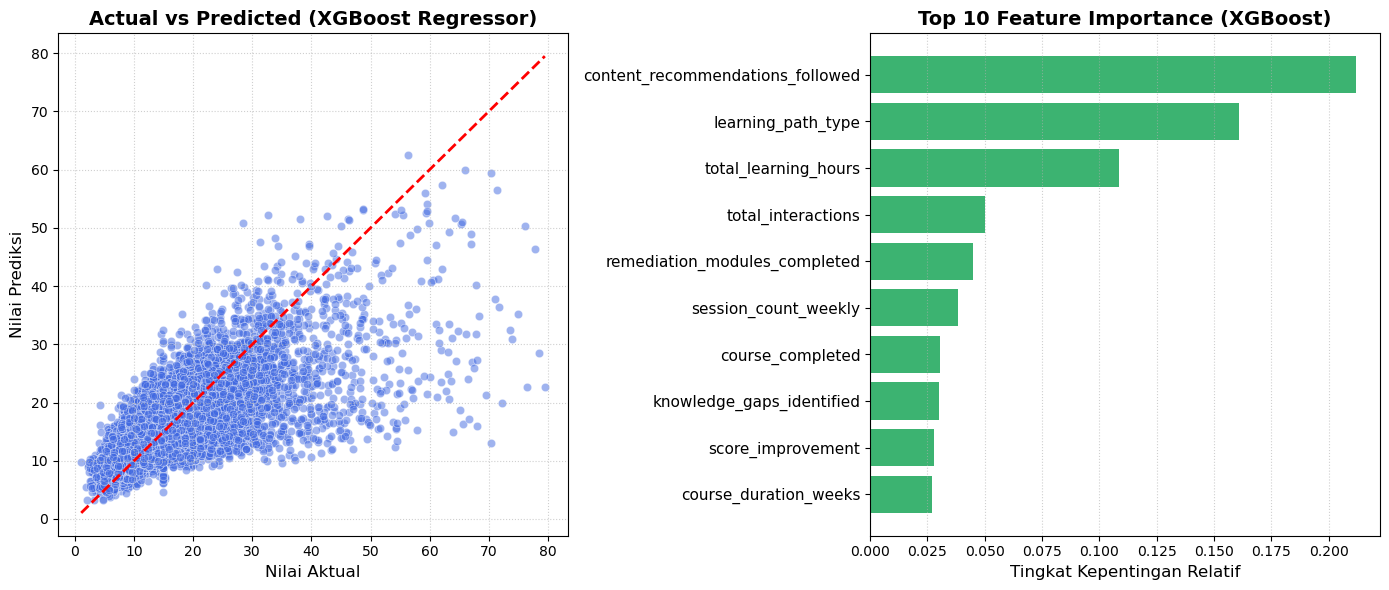

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mengatur ukuran kanvas
plt.figure(figsize=(14, 6))

# 1. Visualisasi Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_r, y=y_pred_xgb, alpha=0.5, color='royalblue')
min_val = min(y_test_r.min(), y_pred_xgb.min())
max_val = max(y_test_r.max(), y_pred_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
plt.title("Actual vs Predicted (XGBoost Regressor)", fontsize=14, fontweight='bold')
plt.xlabel("Nilai Aktual", fontsize=12)
plt.ylabel("Nilai Prediksi", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# 2. Visualisasi Top 10 Feature Importance
plt.subplot(1, 2, 2)
# Mengambil feature importance dari model XGBoost
importances = xgb_model.feature_importances_
feature_names = X_reg.columns
indices = np.argsort(importances)[-10:]

plt.barh(range(len(indices)), importances[indices], color='mediumseagreen')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=11)
plt.title("Top 10 Feature Importance (XGBoost)", fontsize=14, fontweight='bold')
plt.xlabel("Tingkat Kepentingan Relatif", fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## INSERT PREDICTION RESULT INTO DATASET

## PREDICT USING DUMMY DATA

In [62]:
# INSERT PREDICTION RESULT INTO DATASET (XGBoost Regressor)

# Prediksi seluruh dataset menggunakan XGBoost Regressor
# X_reg berasal dari dlanew (ter-scale), y_reg dari dla (skala asli)
# sehingga prediksi langsung menghasilkan nilai skala asli
y_pred_all_xgb = xgb_model.predict(X_reg)

# Masukkan hasil prediksi ke df_final
# pakai .values untuk menghindari index mismatch antara df_final dan hasil prediksi
df_final['Prediksi_LearningEfficiency_XGB'] = y_pred_all_xgb

# Kolom aktual diambil dari dla (skala asli), di-reset index agar sejajar df_final
df_final['Aktual_LearningEfficiency'] = dla['learning_efficiency_score'].reset_index(drop=True)

# Hitung selisih prediksi vs aktual
df_final['Selisih'] = (df_final['Prediksi_LearningEfficiency_XGB'] - df_final['Aktual_LearningEfficiency']).abs()

# Tampilkan hasil
display(
    df_final[['learner_id', 'Aktual_LearningEfficiency', 'Prediksi_LearningEfficiency_XGB', 'Selisih']]
    .head(15)
    .style.format({
        'Aktual_LearningEfficiency'      : '{:.2f}',
        'Prediksi_LearningEfficiency_XGB': '{:.2f}',
        'Selisih'                        : '{:.2f}'
    })
)

print(f"\nTotal baris: {len(df_final)}")
print(f"Range aktual   : {df_final['Aktual_LearningEfficiency'].min():.2f} — {df_final['Aktual_LearningEfficiency'].max():.2f}")
print(f"Range prediksi : {df_final['Prediksi_LearningEfficiency_XGB'].min():.2f} — {df_final['Prediksi_LearningEfficiency_XGB'].max():.2f}")
print(f"Rata-rata selisih (MAE): {df_final['Selisih'].mean():.2f}")

,learner_id,Aktual_LearningEfficiency,Prediksi_LearningEfficiency_XGB,Selisih
0,0,21.05,15.17,5.88
1,1,5.80,10.79,4.99
2,2,6.13,7.06,0.93
3,3,11.41,13.81,2.40
4,4,6.67,10.83,4.16
5,5,27.77,25.77,2.00
8,6,14.94,25.04,10.10
9,7,7.35,15.01,7.66
10,8,11.09,19.94,8.85
11,9,7.80,8.32,0.52



Total baris: 93002
Range aktual   : 0.42 — 84.70
Range prediksi : 1.88 — 71.02
Rata-rata selisih (MAE): 7.07


In [63]:
# Buat data dummy berbasis rata-rata dari X_reg (Data fitur regresi kamu)
dummy_student_reg = X_reg.mean().to_frame().T

# Modifikasi profil siswanya (Contoh: Siswa yang sangat rajin)
dummy_student_reg['total_learning_hours'] = 180.5
dummy_student_reg['gamification_engagement'] = 75000
dummy_student_reg['forum_posts'] = 25
dummy_student_reg['skill_pre_score'] = 85

# Lakukan Prediksi menggunakan XGBoost
prediksi_efisiensi = xgb_model.predict(dummy_student_reg)

# Tampilkan Hasilnya
print("=== HASIL PREDIKSI XGBOOST REGRESSOR ===")
print(f"Profil Siswa: Rajin belajar dan aktif berinteraksi.")
print(f"Prediksi Nilai Efisiensi Belajar (Learning Efficiency Score): {prediksi_efisiensi[0]:.2f}")

=== HASIL PREDIKSI XGBOOST REGRESSOR ===
Profil Siswa: Rajin belajar dan aktif berinteraksi.
Prediksi Nilai Efisiensi Belajar (Learning Efficiency Score): 9.81


---
## <div align="center"> CONCLUSION </div>
---

##### [RQ 1]

Terdapat ketidakseimbangan kelas yang sangat masif pada variabel target penyelesaian kursus, karena terlihat sebagian besar pelajar berakhir menjadi pengguna pasif atau dropout sekitar 69.4% berdasarkan proporsi kelas. Selain itu, distribusi variabel perilaku seperti jam belajar sangat miring ataw bisa dibilang dengan positive skewness, hal itu yang menandakan mayoritas pelajar sangat pasif. Dari situ embuktikan bahwa meskipun akses kursus mudah, mempertahankan komitmen belajar hingga akhir adalah masalah utama.

##### [RQ 2]

Faktor demografi seperti usia, gender, tingkat pendidikan, atau negara asal tidak memiliki pengaruh yang signifikan terhadap keputusan seorang pelajar untuk dropout atau bertahan. Titik jenuh atau dropout dipicu oleh perilaku interaksi pelajar di dalam platform. Dua faktor paling kritis yang memicu dropout adalah :
1. Engagement Consistency - Pelajar yang jadwal loginnya tidak teratur atau sering bolong-bolong memiliki risiko tertinggi untuk gagal.
2. Video Completion Percentage - Pelajar yang sering melakukan skip pada video materi atau tidak menontonnya hingga selesai adalah indikator terkuat hilangnya motivasi belajar.

##### [RQ 3]

Peningkatan kompetensi atau efisiensi belajar tidak terjadi secara instan, melainkan didorong kuat oleh kombinasi dedikasi waktu dan kepatuhan pada kurikulum sistem. Faktor yang secara mutlak paling memengaruhi skor efisiensi belajar adalah :
1. Total Learning Hours - Semakin besar akumulasi waktu riil yang dihabiskan untuk belajar, semakin tinggi efisiensinya, variabel ini menjadi penentu utama.
2. Content Recommendations Followed - Pelajar yang mengambil materi sesuai dengan alur yang direkomendasikan oleh sistem platform terbukti belajar jauh lebih efisien dibandingkan pelajar yang memilih materi secara acak.
3. Daily App Minutes - Durasi belajar harian yang stabil ikut mendongkrak skor kompetensi.

---
## <div align="center"> DEPLOYMENT </div>
---

In [67]:
import joblib

joblib.dump(xgb_model, 'xgboost_mooc_model.pkl')

#Simpan nilai rata-rata X_reg sebagai template (untuk mengatasi variabel dummy)
base_data = X_reg.mean().to_frame().T
joblib.dump(base_data, 'base_data.pkl')

['base_data.pkl']

In [64]:
print("Name: \t\t{}".format(studentName))
print("NIM: \t\t{}".format(studentNIM))
print("Class: \t\t{}".format(studentClass))
print("End: \t\t{}".format(myDate))
print("Device ID: \t{}".format(myDevice))

Name: 		Arya Pannadana, Nikki Tirta Iwan, Wibisana Theomen Kasriady, Alexander William
NIM: 		00000107859, 00000112922 , 00000119106, 00000108937
Class: 		IS411-EL
End: 		2026-05-29 13:24:16.570272
Device ID: 	04b02d9a-5b27-11f1-b958-5ec0b7ae6c97


----

## <div align="center"> Reference </div>

### Input Your Reference Here  (If any):

----